# Downstream representation spaces

Load fold-1 coordinate archives generated on the cluster and render one 6-by-2 PCA and UMAP figure per classification task.

In [21]:
from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np


def find_repo_root(start=Path.cwd()):
    direct_candidates = (start, start / 'eheiss' / 'scbFM', start / 'scbFM')
    candidates = []
    for direct in direct_candidates:
        candidates.extend((direct, *direct.parents))
    for candidate in dict.fromkeys(candidates):
        if (candidate / 'src' / 'analysis').is_dir() and candidate.name == 'scbFM':
            return candidate
    raise FileNotFoundError('Open this notebook from within the scbFM repository.')


SCBFM_ROOT = find_repo_root()
OUTPUT_ROOT = SCBFM_ROOT.parent / 'output' / 'umap_pca'
THESIS_FIGURES = SCBFM_ROOT.parents[1] / 'Master_Thesis' / 'figures'
THESIS_FIGURES.mkdir(parents=True, exist_ok=True)

MODEL_ROWS = [
    ('random_init', 'RI'),
    ('pretrain_sc', 'PT-sc'),
    ('preadapt_sc', 'PA-sc'),
    ('pretrain_bulk', 'PT-bulk'),
    ('preadapt_bulk', 'PA-bulk'),
]
RAW_KEYS = ('raw_all_genes', 'raw_mad1199')
EXPECTED_KEYS = tuple(
    f'{mode}__{model_key}'
    for model_key, _ in MODEL_ROWS
    for mode in ('head_only', 'full_ft')
) + RAW_KEYS
TASKS = [
    ('canc_type_class', 'Five-type cancer classification'),
    ('canc_type_class_33', '33-type cancer classification'),
    ('disease_class', 'Disease classification'),
]

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'figure.titlesize': 11,
    'savefig.facecolor': 'white',
    'figure.facecolor': 'white',
})
print('Coordinate root:', OUTPUT_ROOT)
print('Figure output:', THESIS_FIGURES)

Coordinate root: /Users/enricoheiss/Thesis/eheiss/output/umap_pca
Figure output: /Users/enricoheiss/Thesis/Master_Thesis/figures


In [22]:
def coordinate_path(task_key):
    return OUTPUT_ROOT / task_key / f'{task_key}_coordinates.npz'


def load_task(task_key):
    path = coordinate_path(task_key)
    if not path.is_file():
        raise FileNotFoundError(
            f'Missing {path}. Sync output/umap_pca from the cluster first.'
        )
    with np.load(path, allow_pickle=False) as archive:
        arrays = {key: archive[key].copy() for key in archive.files}
    metadata = json.loads(path.with_suffix('.json').read_text())
    observed = tuple(arrays['representation_keys'].astype(str))
    if observed != EXPECTED_KEYS:
        raise ValueError(
            f'{task_key}: archive uses {observed}; expected the new head/full layout. '
            'Rerun and resync the cluster coordinate job.'
        )
    if metadata.get('cv_fold_number') != 1:
        raise ValueError(f'{task_key}: expected fold 1, got {metadata.get("cv_fold_number")}')
    if metadata.get('global_effective_batch_size') != 64:
        raise ValueError(
            f'{task_key}: full fine-tuning did not use global effective batch size 64.'
        )
    return arrays, metadata


RESULTS = {task_key: load_task(task_key) for task_key, _ in TASKS}
for task_key, (arrays, metadata) in RESULTS.items():
    print(
        f"{task_key:24s} {len(arrays['labels']):5d} held-out observations | "
        f"fold {metadata['cv_fold_number']} | EBS {metadata['global_effective_batch_size']}"
    )

canc_type_class            576 held-out observations | fold 1 | EBS 64
canc_type_class_33        1956 held-out observations | fold 1 | EBS 64
disease_class             5000 held-out observations | fold 1 | EBS 64


In [23]:
def categorical_palette(label_order):
    order = [str(label) for label in label_order]
    if len(order) <= 10:
        colors = plt.get_cmap('tab10')(np.linspace(0, 0.9, max(len(order), 1)))
    elif len(order) <= 20:
        colors = plt.get_cmap('tab20')(np.linspace(0, 0.95, len(order)))
    else:
        colors = plt.get_cmap('turbo')(np.linspace(0.03, 0.97, len(order)))
    return order, {label: colors[index] for index, label in enumerate(order)}


def robust_limits(coordinates):
    lower = np.quantile(coordinates, 0.005, axis=0)
    upper = np.quantile(coordinates, 0.995, axis=0)
    span = np.maximum(upper - lower, 1e-6)
    return lower - 0.05 * span, upper + 0.05 * span


def style_axis(ax, coordinates):
    lower, upper = robust_limits(coordinates)
    ax.set_xlim(lower[0], upper[0])
    ax.set_ylim(lower[1], upper[1])
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def render_task_grid(task_key, method):
    method = method.lower()
    if method not in {'pca', 'umap'}:
        raise ValueError('method must be PCA or UMAP')
    arrays, metadata = RESULTS[task_key]
    labels = arrays['labels'].astype(str)
    label_order, color_lookup = categorical_palette(metadata['label_order'])
    colors = np.asarray([color_lookup[label] for label in labels])
    draw_order = np.random.default_rng(42).permutation(len(labels))
    point_size = 5.0 if len(labels) <= 2_500 else 3.0

    legend_bottom = 0.045 if len(label_order) <= 10 else (0.10 if len(label_order) <= 23 else 0.13)
    fig = plt.figure(figsize=(7.25, 10.4), constrained_layout=False)
    grid = fig.add_gridspec(
        7, 2,
        height_ratios=(1, 1, 1, 1, 1, 0.32, 1),
        left=0.15, right=0.985, top=0.945, bottom=legend_bottom,
        wspace=0.08, hspace=0.10,
    )
    axes = np.empty((6, 2), dtype=object)
    for row in range(5):
        for column in range(2):
            axes[row, column] = fig.add_subplot(grid[row, column])
    for column in range(2):
        axes[5, column] = fig.add_subplot(grid[6, column])

    fig.text(
        0.15, 0.982, 'Benchmark models',
        ha='left', va='center', fontsize=8.5, fontweight='bold',
        color='#333333',
    )
    fig.add_artist(Line2D(
        [0.315, 0.985], [0.982, 0.982], transform=fig.transFigure,
        color='#b8b8b8', linewidth=0.6,
    ))
    for row, (model_key, row_label) in enumerate(MODEL_ROWS):
        for column, mode in enumerate(('head_only', 'full_ft')):
            ax = axes[row, column]
            coordinates = arrays[f'{method}__{mode}__{model_key}'][draw_order]
            ax.scatter(
                coordinates[:, 0], coordinates[:, 1],
                c=colors[draw_order], s=point_size, alpha=0.64,
                linewidths=0, rasterized=True,
            )
            style_axis(ax, coordinates)
            if row == 0:
                ax.set_title(
                    'Frozen Backbone' if column == 0 else 'Fine-Tuned Backbone',
                    pad=7, fontweight='normal',
                )
            if column == 0:
                ax.set_ylabel(
                    row_label, rotation=0, ha='right', va='center',
                    labelpad=12, fontsize=8.5,
                )

    raw_specs = (
        ('raw_all_genes', 'All'),
        ('raw_mad1199', 'MAD'),
    )
    for column, (representation, panel_label) in enumerate(raw_specs):
        ax = axes[5, column]
        coordinates = arrays[f'{method}__{representation}'][draw_order]
        ax.scatter(
            coordinates[:, 0], coordinates[:, 1],
            c=colors[draw_order], s=point_size, alpha=0.64,
            linewidths=0, rasterized=True,
        )
        style_axis(ax, coordinates)
        ax.set_title(panel_label, pad=6, fontsize=8.5, fontweight='normal')
        if column == 0:
            ax.set_ylabel(
                'RE', rotation=0, ha='right', va='center',
                labelpad=12, fontsize=8.5,
            )

    baseline_left = axes[5, 0].get_position().x0
    baseline_right = axes[5, 1].get_position().x1
    baseline_top = axes[5, 0].get_position().y1
    baseline_heading_y = baseline_top + 0.046
    fig.text(
        baseline_left, baseline_heading_y, 'Simple baselines',
        ha='left', va='center', fontsize=8.5, fontweight='bold',
        color='#333333',
    )
    fig.add_artist(Line2D(
        [baseline_left + 0.16, baseline_right],
        [baseline_heading_y, baseline_heading_y],
        transform=fig.transFigure, color='#b8b8b8', linewidth=0.6,
    ))

    handles = [
        Line2D(
            [0], [0], marker='o', linestyle='none', markersize=3.5,
            markerfacecolor=color_lookup[label], markeredgewidth=0, label=label,
        )
        for label in label_order
    ]
    legend_columns = min(5, len(label_order))
    fig.legend(
        handles=handles, loc='lower left', ncol=legend_columns, frameon=False,
        bbox_to_anchor=(0.02, 0.0, 0.96, 0.0), mode='expand',
        fontsize=5.5 if len(label_order) > 10 else 7.0,
        columnspacing=0.8, handletextpad=0.3, borderaxespad=0.0,
    )
    stem = f'{method}_{task_key}_representation_spaces'
    fig.savefig(THESIS_FIGURES / f'{stem}.pdf', bbox_inches='tight')
    fig.savefig(THESIS_FIGURES / f'{stem}.png', dpi=300, bbox_inches='tight')
    return fig

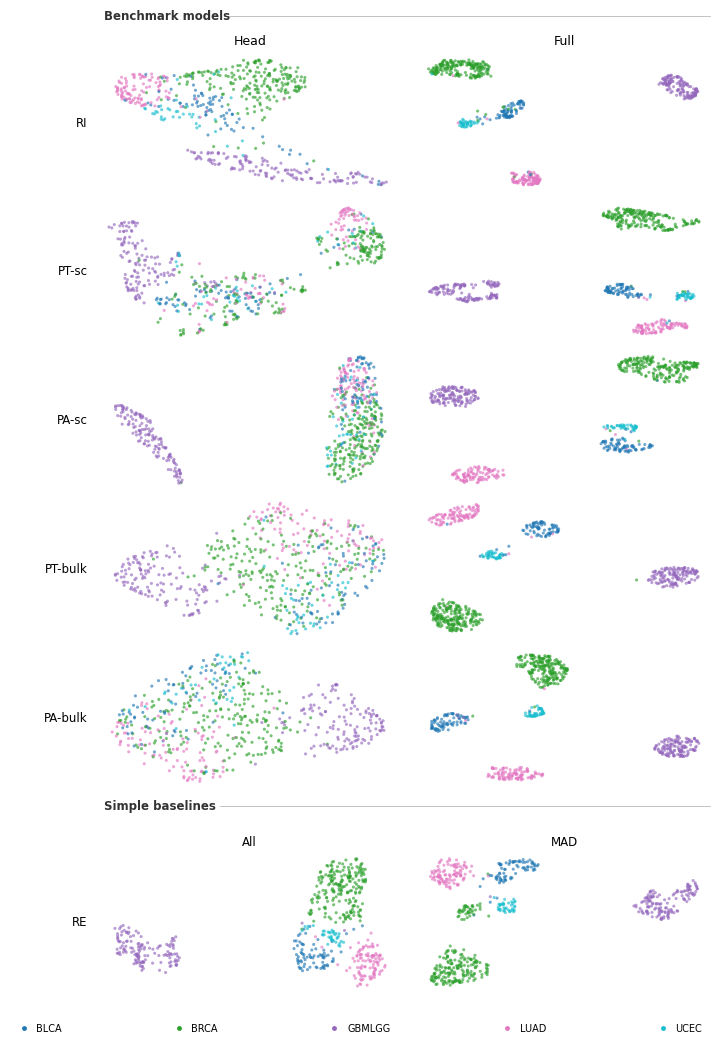

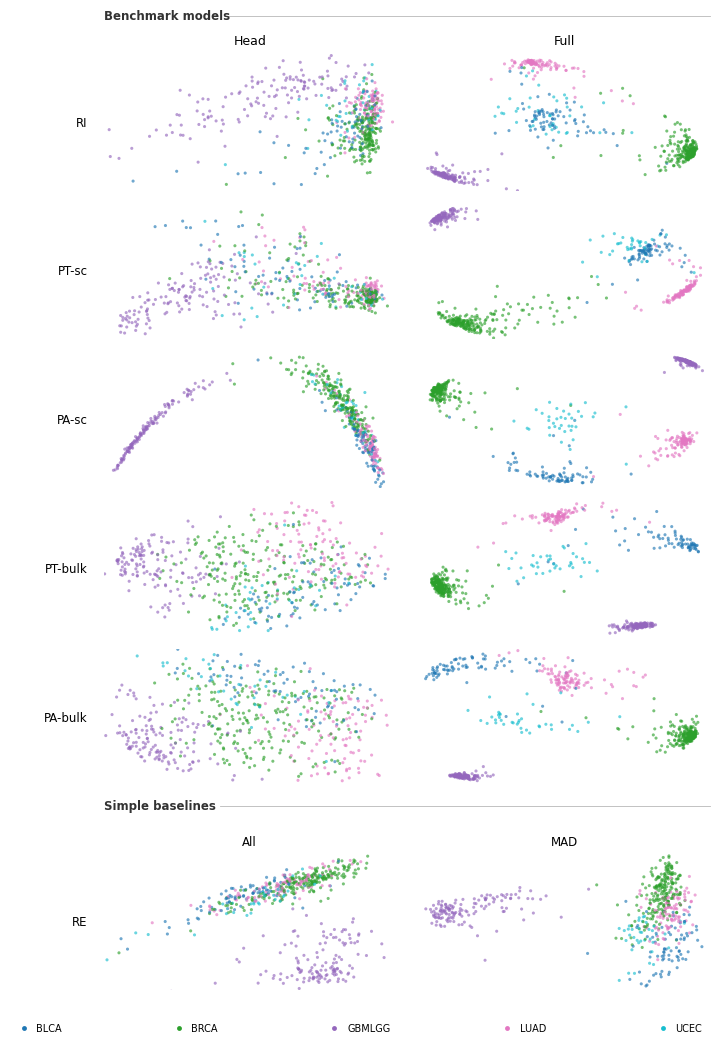

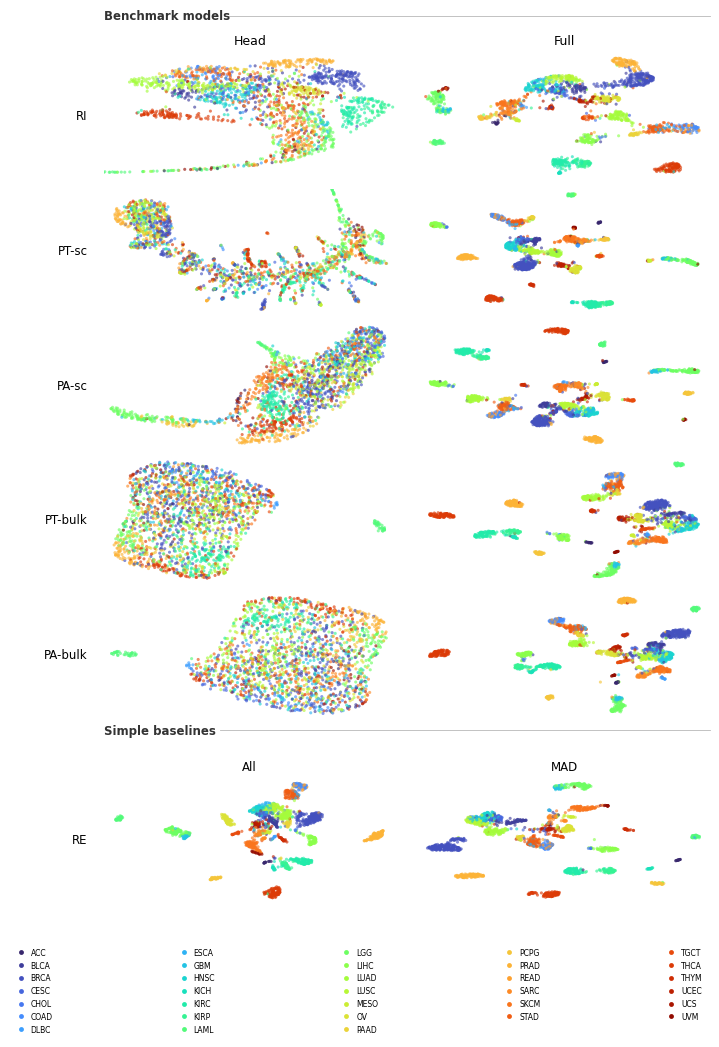

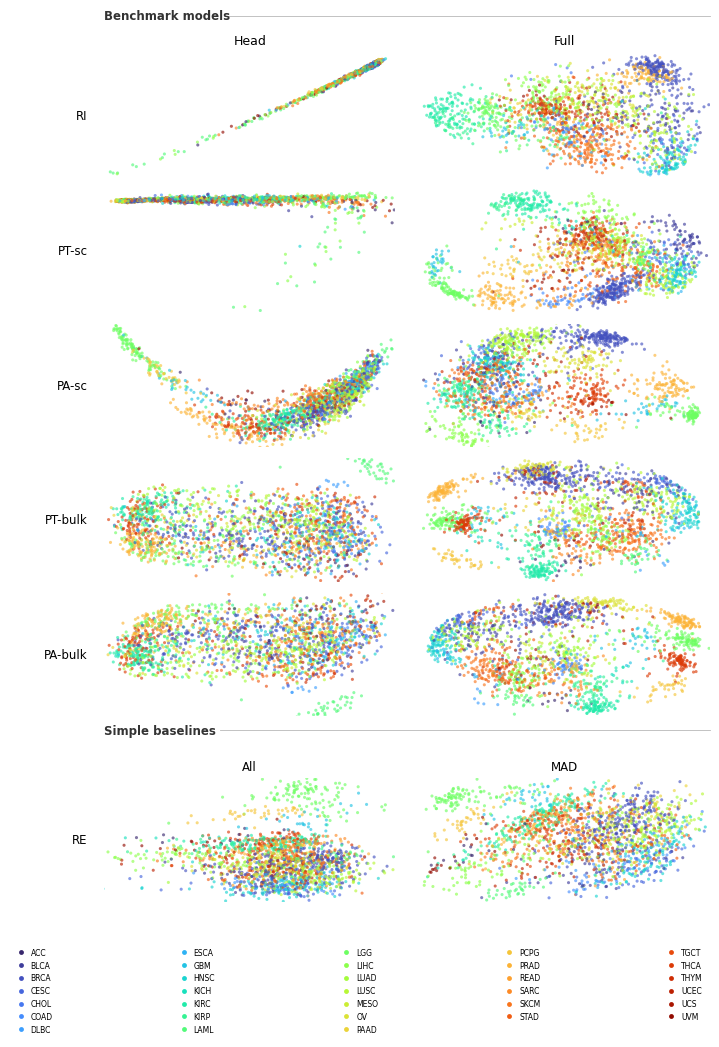

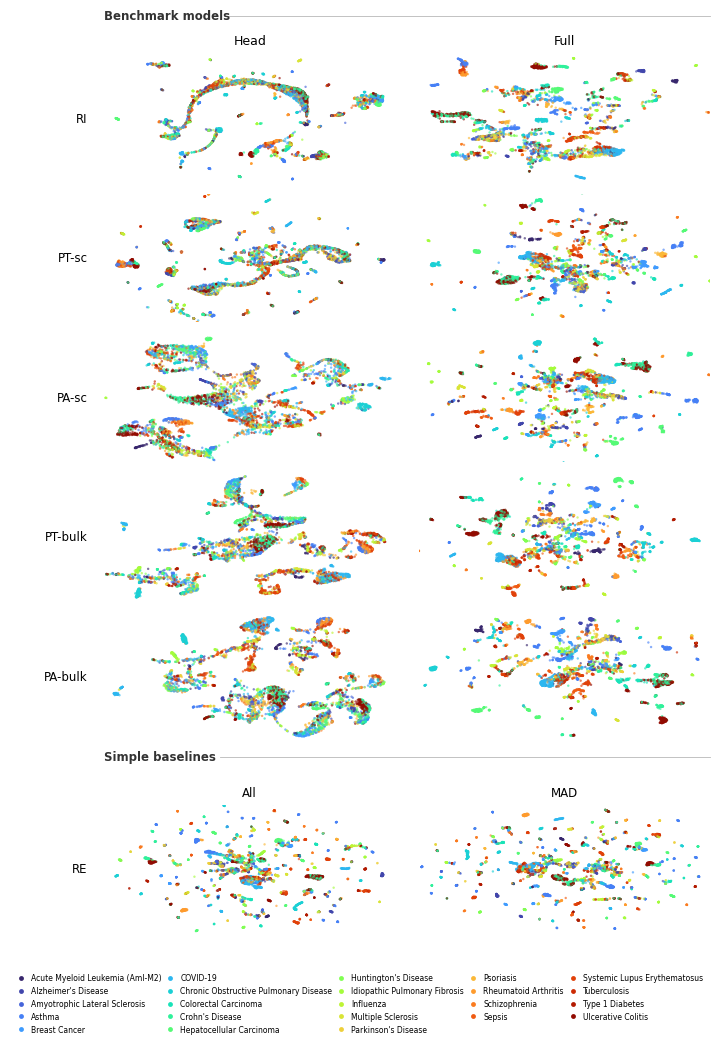

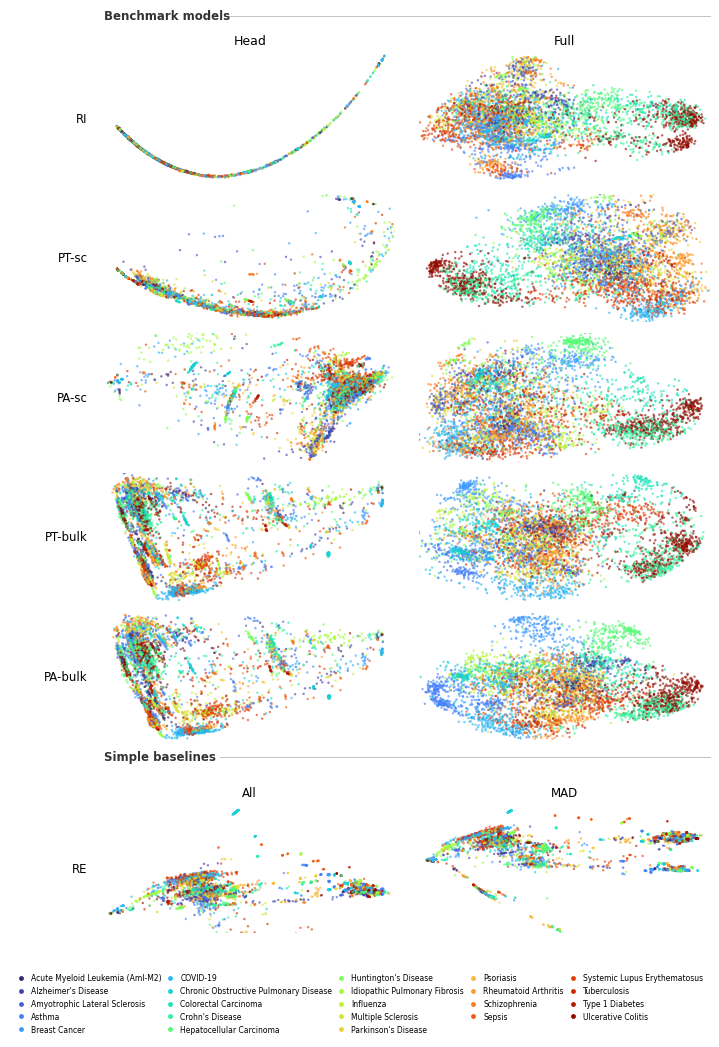

In [24]:
for task_key, _task_title in TASKS:
    for method in ('umap', 'pca'):
        figure = render_task_grid(task_key, method)
        plt.show()
        plt.close(figure)